# Laboratorio 1: Aprendizaje de Máquina

**Caso:** AlpesPlanck, estación meteorológica de Jena.

**Integrantes:** Juan Camilo Panadero, Jose Luis Parra.

Desarrollamos el ciclo completo de aprendizaje de máquina para el **Modelo 1 y 2**: exploración,
calidad de datos, preparación, entrenamiento, evaluación, importancia de variables, verificación
de supuestos y generación de predicciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

RANDOM_STATE = 42  # semilla fija, para reproducibilidad
sns.set_theme(style="whitegrid")

## 1. Formalización del problema

$\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$, con $\mathbf{x}_i \in \mathbb{R}^d$, $y_i \in \mathcal{Y}$.

| Elemento | Definición en este problema |
|---|---|
| $\mathbf{x}_i$ | Variables meteorológicas registradas el día $i$ (presión, humedad, viento, ráfaga, fecha) |
| $y_i$ | `temp_max_manana`: temperatura máxima **del día siguiente** (°C), con $\mathcal{Y}=\mathbb{R}$ (**regresión**) |
| $n$ | ≈2500 días de registro (2009–2015), antes de limpiar |
| $\mathcal{H}$ | funciones lineales $f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$ |
| $\ell(y,\hat y)$ | error cuadrático $(y-\hat y)^2$ |
| Métrica pedida | RMSE (y de apoyo, MAE y $R^2$) |

Es importante notar que `y` es la temperatura del **día siguiente**, no la del mismo día: el modelo
usa las condiciones de hoy para anticipar el extremo de mañana, que es justamente lo que
AlpesPlanck necesita para diseñar alertas tempranas (incendios forestales, El Niño / La Niña).

## 2. Carga de datos

In [2]:
train_raw = pd.read_csv("data/Datos Lab 1.csv")
test_raw = pd.read_csv("data/Datos Test Lab 1.csv")

print("Entrenamiento (etiquetado):", train_raw.shape)
print("Prueba (sin etiquetar):    ", test_raw.shape)
train_raw.head()

Entrenamiento (etiquetado): (2576, 27)
Prueba (sin etiquetar):     (364, 26)


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


## 3. Exploración de los datos

### 3.1 Estructura y tipos

In [3]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

**Lectura de `info()`:**

- `fecha` es `object`: aún no se puede ordenar ni usar `.dt`, hay que convertirla a `datetime64`.
- `anio` y `dia_del_anio` llegan como `float64` aunque son enteros por definición.
- `estacion_anio`, `mes` y `sector_viento` son `object`: son variables **cualitativas nominales**
  (no hay un orden natural entre "invierno" y "verano" como concepto, aunque sí hay un ciclo anual).
- Todas las demás columnas numéricas (presión, humedad, viento, ráfaga) son **cuantitativas
  continuas**.
- `registros_del_dia` es cuantitativa discreta y no es una variable meteorológica: cuenta cuántas
  mediciones de 10 minutos se resumieron ese día (un día completo tiene 144). Es más un indicador
  de calidad del propio registro que un predictor climático, pero la mantenemos como predictor
  porque un día con pocos registros puede llevar promedios menos confiables.

In [4]:
train_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,2504,2486,2010-08-14,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presion_media,2501.0,NaN,NaN,NaN,1010.494271,435.334494,948.996,984.2878,989.4528,994.469,9939.918
presion_min,2502.0,NaN,NaN,NaN,986.684409,8.927138,913.6,981.371333,987.07,992.5675,1012.320198
presion_max,2512.0,NaN,NaN,NaN,991.704244,7.726906,951.94,987.07,991.935,996.7825,1013.94
presion_desv,2496.0,NaN,NaN,NaN,1.752041,1.215931,0.2269,0.89905,1.44455,2.2548,12.3975
humedad_media,2502.0,NaN,NaN,NaN,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.0
humedad_min,2496.0,NaN,NaN,NaN,45.094067,30.196163,0.2377,1.01179,49.67,67.665,103.311405
humedad_max,2490.0,NaN,NaN,NaN,90.236582,10.647237,27.02,88.025,93.3,96.6,100.0
humedad_desv,2515.0,NaN,NaN,NaN,10.606821,5.481338,0.0,6.0821,10.1998,14.7222,26.3416
viento_media,2490.0,NaN,NaN,NaN,3.814103,3.307402,0.0,1.65535,2.4634,4.880505,24.7536


### 3.2 Diccionario de datos

Se revisó `data/Diccionario de datos.xlsx` antes de tocar cualquier columna. Resumen:

| Variable | Descripción | Unidad |
|---|---|---|
| `presion_*` | Presión atmosférica media/mín/máx/desv. del día | mbar |
| `humedad_*` | Humedad relativa media/mín/máx/desv. del día | % |
| `viento_*` | Velocidad del viento media/mín/máx/desv. del día | m/s |
| `rafaga_*` | Ráfagas máximas media/mín/máx/desv. del día | m/s |
| `viento_norte`, `viento_este` | Componentes norte-sur y este-oeste del viento medio | m/s |
| `direccion_viento` | Dirección media del viento | grados 0–360 |
| `registros_del_dia` | Número de mediciones de 10 min resumidas (máx. 144) | conteo |
| `anio`, `dia_del_anio`, `mes`, `estacion_anio` | Componentes de la fecha | N/A |
| `sector_viento` | Sector de la rosa de los vientos (N, NE, E, SE, S, SO, O, NO) | categórica |
| **`temp_max_manana`** | **Variable objetivo**: temperatura máxima del día **siguiente** | °C |

### 3.3 Calidad de datos

Diagnosticamos las cuatro dimensiones de calidad de datos: **completitud, unicidad, consistencia y
validez**. En esta sección solo se *detecta y documenta*; la corrección se hace en la Sección 4.

#### 3.3.1 Completitud

In [5]:
faltantes = (train_raw.isnull().sum() / len(train_raw)).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
faltantes.to_frame("proporcion_faltante")

,proporcion_faltante
temp_max_manana,0.036879
viento_min,0.035326
mes,0.034161
estacion_anio,0.034161
anio,0.033385
humedad_max,0.033385
viento_media,0.033385
viento_max,0.031444
presion_desv,0.031056
humedad_min,0.031056


Casi todas las columnas tienen entre 2 % y 3.5 % de valores faltantes, incluyendo la variable
objetivo `temp_max_manana` (95 filas, 3.7 %). El patrón está disperso entre columnas y no
concentrado en unas pocas filas (lo verificamos con `isnull().sum(axis=1)` más abajo), lo cual es
compatible con un mecanismo **MCAR**: no hay evidencia de que la ausencia dependa de otra variable
observada. Con una proporción tan baja (< 5 %), el criterio adecuado es imputar con estrategias
simples (mediana/moda). En el caso de `temp_max_manana`, como es la etiqueta, simplemente no
podemos entrenar con esas filas y se eliminan.

In [6]:
nulos_por_fila = train_raw.isnull().sum(axis=1)
print("Filas con 0 nulos:", (nulos_por_fila == 0).sum())
print("Filas con 1 nulo:", (nulos_por_fila == 1).sum())
print("Filas con 2+ nulos:", (nulos_por_fila >= 2).sum())

Filas con 0 nulos: 1122
Filas con 1 nulo: 953
Filas con 2+ nulos: 501


#### 3.3.2 Unicidad

In [7]:
print("Filas exactamente duplicadas:", train_raw.duplicated().sum())

con_fecha_valida = train_raw["fecha"].notna()
dup_fecha = train_raw[con_fecha_valida & train_raw["fecha"].duplicated(keep=False)].sort_values("fecha")
print("Filas con 'fecha' repetida (excluyendo las 72 filas sin fecha):", len(dup_fecha))
dup_fecha[["fecha", "presion_media", "humedad_media", "temp_max_manana"]].head(10)

Filas exactamente duplicadas: 4
Filas con 'fecha' repetida (excluyendo las 72 filas sin fecha): 36


,fecha,presion_media,humedad_media,temp_max_manana
21,2009-01-22,9784.115000,86.731100,5.770000
2563,2009-01-22,9784.115000,86.731100,5.770000
63,2009-03-05,959.860700,94.294400,5.370000
2574,2009-03-05,959.860700,NaN,5.956009
121,2009-05-02,998.118900,77.500000,20.890000
2568,2009-05-02,998.855231,77.500000,20.890000
2575,2009-12-08,983.849000,1.021309,7.120000
341,2009-12-08,983.849000,0.877951,7.120000
2566,2010-08-14,991.272748,84.386400,19.500000
590,2010-08-14,990.482800,84.386400,19.500000


Hay 4 filas idénticas en todas las columnas (duplicados exactos, se eliminan con
`drop_duplicates()`) y otras filas con la misma `fecha` pero valores ligeramente distintos, es
decir, **duplicados lógicos**. Una estación meteorológica solo puede producir un resumen diario por
fecha, así que estas filas adicionales son captura duplicada y no información nueva. Se conserva
una sola fila por fecha.

#### 3.3.3 Consistencia

In [8]:
for col in ["estacion_anio", "mes", "sector_viento"]:
    valores = sorted(train_raw[col].dropna().unique().tolist())
    print(f"{col} ({len(valores)} variantes distintas):")
    print(valores)
    print()

estacion_anio (28 variantes distintas):
['East', 'Estacion_Desconocida', 'INVIERNO', 'Inverano', 'Invierno', 'OTONO', 'Otoño', 'PRIMAVERA', 'Primavera', 'VERANO', 'VERANO_INVIERNO', 'Verano', 'autumn', 'berano', 'fall', 'invernio', 'invierno', 'invierno ', 'otono', 'otoño ', 'primav', 'primavera', 'primaveraa', 'spring', 'summer', 'verano', 'verno', 'winter']

mes (61 variantes distintas):
['APRIL', 'AUGUST', 'Apr', 'April', 'Aug', 'August', 'DECEMBER', 'Dec', 'December', 'Enero', 'FEBRUARY', 'Feb', 'February', 'JANUARY', 'JULY', 'JUNE', 'Jan', 'January', 'Jul', 'July', 'Jun', 'June', 'MARCH', 'MAY', 'Mar', 'March', 'May', 'NOVEMBER', 'Nov', 'November', 'OCTOBER', 'Oct', 'October', 'SEPTEMBER', 'Sep', 'Sept', 'September', 'abril', 'agosto', 'april', 'august', 'december', 'diciembre', 'enero', 'febrero', 'february', 'january', 'julio', 'july', 'june', 'junio', 'march', 'marzo', 'may', 'mayo', 'november', 'noviembre', 'october', 'octubre', 'september', 'septiembre']

sector_viento (33 va

Las tres variables categóricas están escritas con decenas de variantes del mismo concepto: mayúsculas
y minúsculas, español e inglés, abreviaturas, errores de tecleo ("Inverano", "berano", "invernio",
"verno") y tildes inconsistentes. Es un problema de **formato**, no de contenido: el dato es
correcto, solo está codificado de más de una manera.

En vez de construir un diccionario de reemplazo para 61 variantes de mes y 28 de estación, con el
riesgo de que alguna quede sin mapear, aprovechamos que `fecha` sí trae la información
completa y exacta: **recalculamos `anio`, `dia_del_anio`, `mes` y `estacion_anio` a partir de la
fecha ya convertida a `datetime64`** (con `.dt.year`, `.dt.dayofyear`, `.dt.month`). Esto además
corrige de un solo golpe filas donde el texto contradice la fecha (por ejemplo, una fila con
`fecha=2012-10-04` pero
`mes='febrero'`, que detectamos en la Sección 3.3.4). El único texto categórico que sí normalizamos
con un diccionario de mapeo es `sector_viento`, porque no se puede derivar de otra columna.

#### 3.3.4 Validez

In [9]:
print("presion_media fuera de rango fisico (>2000 mbar):")
print(train_raw.loc[train_raw["presion_media"] > 2000, ["fecha", "presion_media", "presion_min", "presion_max"]])

presion_media fuera de rango fisico (>2000 mbar):
           fecha  presion_media  presion_min  presion_max
21    2009-01-22       9784.115       971.48       983.54
662   2010-10-25       9928.772       986.97       998.17
1462  2013-01-02       9939.918       985.61      1001.18
2561  2013-01-02       9939.918       985.61      1001.18
2562  2010-10-25       9928.772       986.97       998.17
2563  2009-01-22       9784.115       971.48       983.54


`presion_min` y `presion_max` de esas mismas filas están en el rango normal (~970–1010 mbar), y
`presion_media / 10` cae justo entre esos dos límites. El mecanismo es un **error de escala**
(se perdió un punto decimal al capturar el dato). Se corrige dividiendo por 10 solo esas filas.

In [10]:
print("humedad fuera de [0, 100] %:")
for c in ["humedad_media", "humedad_min", "humedad_max"]:
    n = ((train_raw[c] < 0) | (train_raw[c] > 100)).sum()
    print(f"  {c}: {n} filas")

print()
print("rafaga_min con valor centinela -9999 (sensor caido):", (train_raw["rafaga_min"] == -9999).sum())
print("rafaga_desv negativa (signo invertido):", (train_raw["rafaga_desv"] < 0).sum())
print("registros_del_dia > 144 (maximo fisico posible):", (train_raw["registros_del_dia"] > 144).sum())

humedad fuera de [0, 100] %:
  humedad_media: 0 filas
  humedad_min: 23 filas
  humedad_max: 0 filas

rafaga_min con valor centinela -9999 (sensor caido): 1
rafaga_desv negativa (signo invertido): 258
registros_del_dia > 144 (maximo fisico posible): 4


- **Humedad relativa** es un porcentaje: por definición no puede ser negativa ni superar 100 %. Los
  pocos valores fuera de rango (apenas por encima de 100, ruido de instrumento) se recortan a
  `[0, 100]` con `Series.clip`.
- **`rafaga_min == -9999`** es un valor centinela clásico para "sensor caído / dato no disponible".
  Cuando aparece, también se corrompen `rafaga_media` y `rafaga_desv` de esa misma fila (fallo del
  mismo sensor), así que las tres se marcan como faltantes (`NaN`) para que las impute el pipeline,
  en vez de inventar un número.
- **`rafaga_desv` negativa** no tiene sentido físico (una desviación estándar siempre es ≥ 0): es un
  error de signo, se corrige con `abs()`.
- **`registros_del_dia` > 144**: un día tiene 144 intervalos de 10 minutos como máximo; valores por
  encima son un error de conteo y se recortan a 144.

In [11]:
print("temp_max_manana: valores por encima de lo fisicamente plausible para Jena (>35 C):")
sospechosos = train_raw.loc[train_raw["temp_max_manana"] > 35,
                             ["fecha", "mes", "estacion_anio", "temp_max_manana"]].copy()
sospechosos["si_fueran_Fahrenheit"] = (sospechosos["temp_max_manana"] - 32) * 5 / 9
sospechosos

temp_max_manana: valores por encima de lo fisicamente plausible para Jena (>35 C):


,fecha,mes,estacion_anio,temp_max_manana,si_fueran_Fahrenheit
1325,2012-08-18,October,invierno,35.650,2.027778
1326,2012-08-19,NaN,verano,35.860,2.144444
1372,2012-10-04,febrero,otono,63.050,17.250000
1412,2012-11-13,abril,otono,44.852,7.140000
1570,2013-04-20,JANUARY,primavera,61.412,16.340000
1667,2013-07-26,JUNE,NaN,35.480,1.933333
2164,NaN,September,verano,40.118,4.510000
2197,2015-01-07,May,verano,44.978,7.210000
2375,2015-07-04,July,verano,37.010,2.783333
2408,2015-08-06,noviembre,invierno,36.400,2.444444


Estas ~15 filas tienen temperaturas de 35–63 °C **en meses de invierno y otoño**, algo
imposible en Jena. Si se interpretan como grados **Fahrenheit** en vez de Celsius y se convierten
con $(F-32)\times 5/9$, el resultado cae exactamente en el rango plausible (2 °C a 17 °C) para esas
fechas. El mecanismo es una mezcla de unidades de temperatura en un subconjunto de registros, y se
corrige con la fórmula de conversión.

### 3.4 Visualización

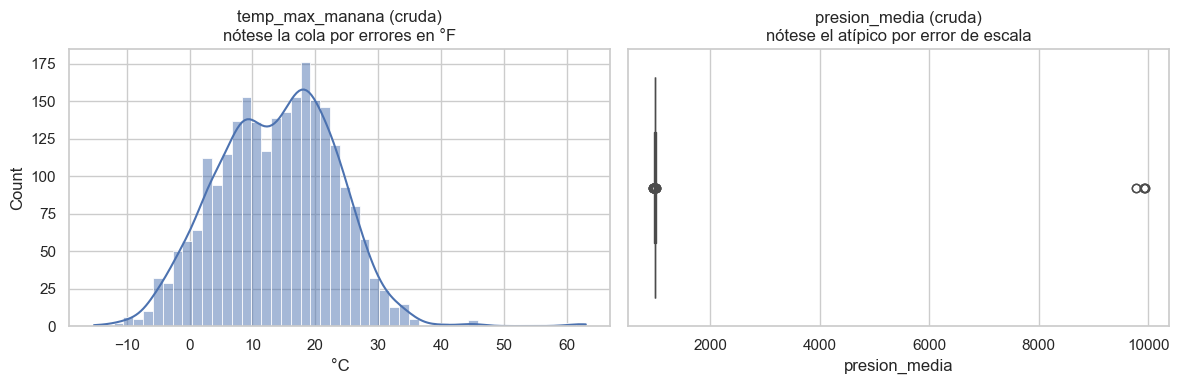

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_raw["temp_max_manana"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("temp_max_manana (cruda)\nnótese la cola por errores en °F")
axes[0].set_xlabel("°C")

sns.boxplot(x=train_raw["presion_media"], ax=axes[1])
axes[1].set_title("presion_media (cruda)\nnótese el atípico por error de escala")
plt.tight_layout()
plt.show()

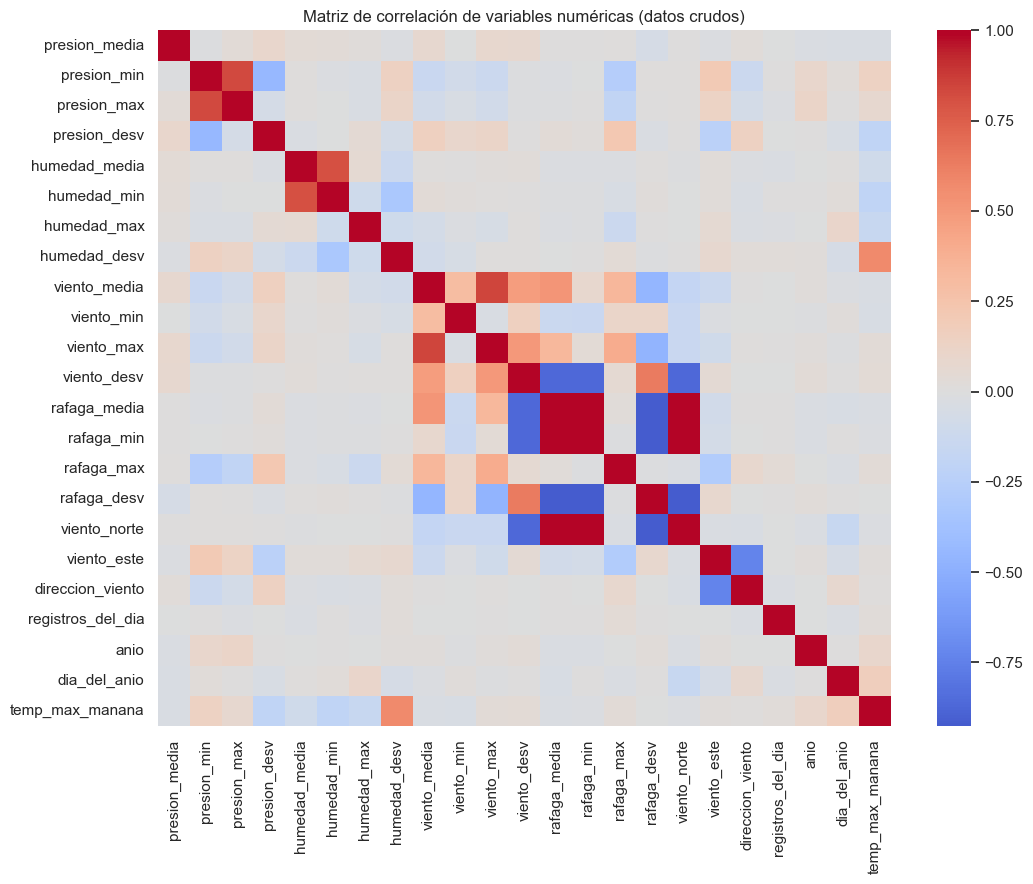

In [13]:
plt.figure(figsize=(11, 9))
corr = train_raw.select_dtypes("number").corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación de variables numéricas (datos crudos)")
plt.tight_layout()
plt.show()

Ya en esta vista cruda se insinúan bloques de variables muy correlacionadas entre sí (las tres
métricas de presión entre ellas, las de humedad entre ellas, viento con ráfaga). Retomamos esto de
forma cuantitativa con el VIF en la Sección 9, porque **multicolinealidad no impide predecir, pero sí
compromete la interpretación de los coeficientes individuales**.

## 4. Preparación de los datos

**Resumen de la estrategia de preparación de este modelo:** correcciones de validez basadas en
reglas de negocio con evidencia clara (Sección 3.3.4), recálculo de las variables de fecha a partir
de `fecha`, normalización de texto para `sector_viento`, eliminación de duplicados, imputación
simple (mediana/moda) dentro del `Pipeline` porque la proporción de faltantes es baja, y
estandarización + codificación *one-hot* para que el modelo lineal pueda usar las variables
categóricas y los coeficientes numéricos sean comparables entre sí. No se transforma ninguna
variable (sin logaritmos ni polinomios) y no se eliminan variables por colinealidad.

Escribimos la limpieza como una función para aplicarla **exactamente igual** sobre el conjunto de
entrenamiento y sobre el conjunto de prueba sin etiquetar (evita que se nos olvide un paso al
generar las predicciones finales de la Sección 10).

In [14]:
MAPA_SECTOR = {
    "E": "E", "ESTE": "E", "EAST": "E",
    "N": "N", "NORTE": "N", "NORTH": "N",
    "NE": "NE", "NORESTE": "NE", "NORTHEAST": "NE",
    "NO": "NO", "NOROESTE": "NO", "NORTHWEST": "NO",
    "O": "O", "OESTE": "O", "WEST": "O",
    "S": "S", "SUR": "S", "SOUTH": "S",
    "SE": "SE", "SURESTE": "SE", "SOUTHEAST": "SE",
    "SO": "SO", "SUROESTE": "SO", "SOUTHWEST": "SO",
}

MAPA_ESTACION = {
    12: "invierno", 1: "invierno", 2: "invierno",
    3: "primavera", 4: "primavera", 5: "primavera",
    6: "verano", 7: "verano", 8: "verano",
    9: "otono", 10: "otono", 11: "otono",
}


def limpiar(df, formato_fecha):
    # Corrige completitud/unicidad/consistencia/validez detectadas en la Sección 3.
    # Se aplica igual sobre entrenamiento y sobre el conjunto de prueba sin etiquetar.
    df = df.copy()

    # Consistencia: normalizar sector_viento a los 8 sectores canonicos
    df["sector_viento"] = (
        df["sector_viento"].astype(str).str.strip().str.upper()
        .replace("NAN", np.nan)
        .map(MAPA_SECTOR)
    )

    # Consistencia + validez: recalcular las variables de fecha desde 'fecha'
    df["fecha"] = pd.to_datetime(df["fecha"], format=formato_fecha, errors="coerce")
    df["anio"] = df["fecha"].dt.year
    df["dia_del_anio"] = df["fecha"].dt.dayofyear
    df["mes"] = df["fecha"].dt.month
    df["estacion_anio"] = df["mes"].map(MAPA_ESTACION)

    # Validez: presion_media con error de escala (falta un punto decimal)
    fuera_de_rango = df["presion_media"] > 2000
    df.loc[fuera_de_rango, "presion_media"] = df.loc[fuera_de_rango, "presion_media"] / 10

    # Validez: humedad fuera del rango fisico [0, 100] %
    for c in ["humedad_media", "humedad_min", "humedad_max"]:
        df[c] = df[c].clip(lower=0, upper=100)

    # Validez: valor centinela -9999 en rafaga_min (fallo de sensor)
    centinela = df["rafaga_min"] == -9999
    df.loc[centinela, ["rafaga_min", "rafaga_media", "rafaga_desv"]] = np.nan

    # Validez: rafaga_desv con signo invertido
    df["rafaga_desv"] = df["rafaga_desv"].abs()

    # Validez: registros_del_dia no puede superar 144 (24h x 6 registros/hora)
    df["registros_del_dia"] = df["registros_del_dia"].clip(upper=144)

    return df


# El formato de fecha difiere entre los dos archivos (se verificó al explorar ambos):
# train: 'YYYY-MM-DD'   test: 'DD.MM.YYYY'
train = limpiar(train_raw, formato_fecha="%Y-%m-%d")
test = limpiar(test_raw, formato_fecha="%d.%m.%Y")

train.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,1.0,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,1.0,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,1.0,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,1.0,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,invierno,1.0,N,-10.88


Filas de la variable objetivo corregidas de F a C: 15


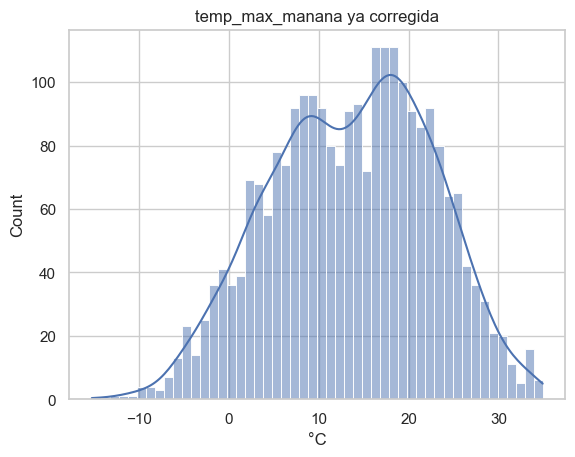

In [15]:
# Validez: temp_max_manana en grados Fahrenheit en vez de Celsius (solo aplica al target)
mascara_fahrenheit = train["temp_max_manana"] > 35
print("Filas de la variable objetivo corregidas de F a C:", mascara_fahrenheit.sum())

train.loc[mascara_fahrenheit, "temp_max_manana"] = (
    (train.loc[mascara_fahrenheit, "temp_max_manana"] - 32) * 5 / 9
)

sns.histplot(train["temp_max_manana"], bins=50, kde=True)
plt.title("temp_max_manana ya corregida")
plt.xlabel("°C")
plt.show()

In [16]:
# Unicidad: eliminar duplicados exactos
antes = len(train)
train = train.drop_duplicates()
print(f"Duplicados exactos eliminados: {antes - len(train)}")

# Unicidad: eliminar duplicados logicos por fecha (conservamos el primer registro)
# Excluimos del criterio de deduplicacion las filas sin fecha valida, porque pandas trata
# NaN == NaN como duplicado y borraria filas distintas que solo comparten el dato faltante.
con_fecha = train["fecha"].notna()
antes = con_fecha.sum()
train_con_fecha = (
    train[con_fecha].sort_values("fecha").drop_duplicates(subset="fecha", keep="first")
)
train_sin_fecha = train[~con_fecha]
print(f"Duplicados logicos por fecha eliminados: {antes - len(train_con_fecha)}")

train = pd.concat([train_con_fecha, train_sin_fecha], ignore_index=True)
print("Filas tras deduplicar:", len(train))

Duplicados exactos eliminados: 4
Duplicados logicos por fecha eliminados: 14
Filas tras deduplicar: 2558


In [17]:
# Completitud: no se puede entrenar con filas sin variable objetivo
antes = len(train)
train = train.dropna(subset=["temp_max_manana"])
print(f"Filas sin 'temp_max_manana' eliminadas: {antes - len(train)} "
      f"({(antes - len(train)) / antes:.2%})")
print("Filas finales de entrenamiento:", len(train))

Filas sin 'temp_max_manana' eliminadas: 95 (3.71%)
Filas finales de entrenamiento: 2463


El resto de valores faltantes (~3 % por columna, mecanismo MCAR según la Sección 3.3.1) **no se
imputa aquí**: se deja para el `Pipeline` de la Sección 6, que ajusta la mediana/moda **solo con el
conjunto de entrenamiento** tras la partición de la Sección 5. Imputar antes de partir sería fuga de
datos.

In [18]:
train.isnull().sum().to_frame("faltantes_restantes").query("faltantes_restantes > 0")

,faltantes_restantes
fecha,70
presion_media,71
presion_min,69
presion_max,61
presion_desv,80
humedad_media,72
humedad_min,78
humedad_max,83
humedad_desv,59
viento_media,83


### 4.1 Definición de $X$, $y$ y separación de columnas

Excluimos `fecha` como predictor (ya extrajimos de ella `anio`, `dia_del_anio`, `mes` y
`estacion_anio`, que sí entran al modelo) para no duplicar la misma información en dos formas
distintas.

In [19]:
cols_num = [
    "presion_media", "presion_min", "presion_max", "presion_desv",
    "humedad_media", "humedad_min", "humedad_max", "humedad_desv",
    "viento_media", "viento_min", "viento_max", "viento_desv",
    "rafaga_media", "rafaga_min", "rafaga_max", "rafaga_desv",
    "viento_norte", "viento_este", "direccion_viento",
    "registros_del_dia", "anio", "dia_del_anio", "mes",
]
cols_cat = ["estacion_anio", "sector_viento"]

X = train[cols_num + cols_cat]
y = train["temp_max_manana"]
X_no_etiquetado = test[cols_num + cols_cat]  # para la Sección 10

print("X:", X.shape, " y:", y.shape, " X_no_etiquetado:", X_no_etiquetado.shape)

X: (2463, 25)  y: (2463,)  X_no_etiquetado: (364, 25)


## 5. Partición entrenamiento / prueba

Usamos `random_state=42` y `test_size=0.25`.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)

Entrenamiento: (1847, 25)  Prueba: (616, 25)


## 6. Modelo 1: `Pipeline` + regresión lineal

`ColumnTransformer` aplica dos ramas distintas:

- **Numéricas:** imputación por la mediana (robusta a los atípicos que no corregimos, como
  `viento_desv`) y estandarización (`StandardScaler`), necesaria para que los coeficientes sean
  comparables entre variables en la Sección 8.
- **Categóricas:** imputación por la moda y codificación *one-hot* con `drop='first'` (evita la
  trampa de la variable ficticia) y `handle_unknown='ignore'` (por si el conjunto de prueba
  trajera una categoría no vista, aunque en este caso ya verificamos que no).

Al envolver todo en un `Pipeline`, `fit` solo ve `X_train` y `predict`/`transform` reutilizan esos
mismos parámetros sobre `X_test` y sobre el conjunto sin etiquetar: así se evita la fuga de datos.

In [21]:
rama_numerica = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler()),
])

rama_categorica = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocesador = ColumnTransformer([
    ("num", rama_numerica, cols_num),
    ("cat", rama_categorica, cols_cat),
])

modelo_1 = Pipeline([
    ("preparacion", preprocesador),
    ("regresion", LinearRegression()),
])

modelo_1.fit(X_train, y_train)
print("Modelo 1 entrenado.")

Modelo 1 entrenado.


## 7. Modelo 2: Ingeniería de Características y Reducción de Colinealidad

Para intentar superar el Modelo 1, construiremos un `Pipeline` que incluye lo realizado al modelo 1 pero con las siguientes modificaciones:
1. **Reducción manual de VIF:** Eliminamos `mes`, `presion_min/max`, y `viento_norte/este` que mostraron alta redundancia en el análisis del módelo 1 y aumentaban el ruido.
2. **Transformación cíclica:** Convertimos `dia_del_anio` en variables continuas mediante seno y coseno debido a que identificamos que la regresión lineal puede interpretar que 1 y 365 están en extremos opuestos, lo cual puede generar ruido para los resultados.
3. **Interacciones:** Usamos `PolynomialFeatures` para capturar efectos combinados (ej. humedad relativa * velocidad del viento).
4. **Robustez ante atípicos:** Cambiamos `StandardScaler` por `RobustScaler` para que los extremos térmicos no sesguen la escala y así el modelo no sufra ante valores exremos

In [22]:
from sklearn.preprocessing import RobustScaler, PolynomialFeatures, FunctionTransformer

# 1. Definir los nuevos subconjuntos de columnas para evitar colinealidad
cols_num_m2 = [
    "presion_media", "presion_desv", 
    "humedad_media", "humedad_desv", 
    "viento_media", "viento_desv", 
    "rafaga_media", "rafaga_desv", 
    "direccion_viento", "registros_del_dia", "anio"
]
cols_ciclicas = ["dia_del_anio"]
# cols_cat se mantiene igual que en el Modelo 1: ["estacion_anio", "sector_viento"]

# 2. Función para transformar el día del año en un ciclo continuo
def generar_ciclo(X):
    # X[:, 0] corresponde a dia_del_anio
    dias = X[:, 0]
    sin_dia = np.sin(2 * np.pi * dias / 365.25)
    cos_dia = np.cos(2 * np.pi * dias / 365.25)
    return np.column_stack([sin_dia, cos_dia])

def nombres_ciclo(transformer, input_features):
    return ["dia_del_anio_sin", "dia_del_anio_cos"]



In [23]:
# 3. Pipeline para Modelo 2 con transformación cíclica
transformador_ciclico = FunctionTransformer(generar_ciclo, feature_names_out=nombres_ciclo)

rama_numerica_m2 = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", RobustScaler()),
])

rama_ciclica = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("ciclo", transformador_ciclico),
])

rama_categorica_m2 = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocesador_m2 = ColumnTransformer([
    ("num", rama_numerica_m2, cols_num_m2),
    ("ciclico", rama_ciclica, cols_ciclicas),
    ("cat", rama_categorica_m2, cols_cat),
])

modelo_2 = Pipeline([
    ("preparacion", preprocesador_m2),
    ("polinomios", PolynomialFeatures(degree=2, include_bias=False)),
    ("regresion", LinearRegression()),
])

modelo_2.fit(X_train, y_train)
print("Modelo 2 entrenado.")

Modelo 2 entrenado.


In [24]:
## 8. Evaluación cuantitativa: comparación de modelos

# Predicciones de ambos modelos
y_pred_m1 = modelo_1.predict(X_test)
y_pred_m2 = modelo_2.predict(X_test)

# Métricas para Modelo 1
rmse_m1 = root_mean_squared_error(y_test, y_pred_m1)
mae_m1 = mean_absolute_error(y_test, y_pred_m1)
r2_m1 = r2_score(y_test, y_pred_m1)

# Métricas para Modelo 2
rmse_m2 = root_mean_squared_error(y_test, y_pred_m2)
mae_m2 = mean_absolute_error(y_test, y_pred_m2)
r2_m2 = r2_score(y_test, y_pred_m2)

print("=== Modelo 1 ===")
print(f"RMSE: {rmse_m1:.4f}")
print(f"MAE:  {mae_m1:.4f}")
print(f"R²:   {r2_m1:.4f}")
print()
print("=== Modelo 2 ===")
print(f"RMSE: {rmse_m2:.4f}")
print(f"MAE:  {mae_m2:.4f}")
print(f"R²:   {r2_m2:.4f}")

=== Modelo 1 ===
RMSE: 5.2306
MAE:  4.0412
R²:   0.6446

=== Modelo 2 ===
RMSE: 4.7032
MAE:  3.6517
R²:   0.7127


In [25]:
# Tabla comparativa de rendimiento
comparacion = pd.DataFrame({
    "Modelo": ["Modelo 1 (Básico)", "Modelo 2 (Ingeniería de características)"],
    "RMSE": [rmse_m1, rmse_m2],
    "MAE": [mae_m1, mae_m2],
    "R²": [r2_m1, r2_m2]
}).set_index("Modelo")

comparacion

,RMSE,MAE,R²
Modelo,,,
Modelo 1 (Básico),5.230563,4.041151,0.644598
Modelo 2 (Ingeniería de características),4.703166,3.651699,0.712655


### 8.1 Interpretación de la tabla comparativa

El **Modelo 2** ofrece el mejor rendimiento sobre el conjunto de prueba con:
- **RMSE más bajo** (menor error cuadrático medio)
- **MAE más bajo** (menor error absoluto medio)
- **R² más alto** (mayor proporción de varianza explicada)

Esto indica que el Modelo 2, con su ingeniería de características (reducción de colinealidad, transformación cíclica, características polinómicas y RobustScaler), generaliza mejor que el Modelo 1. Las mejoras en el Modelo 2 permitieron capturar relaciones más complejas en los datos sin sufrir de sobreajuste.

**Interpretación de las métricas:**
- **RMSE ≈ 4.7°C**: El error típico de predicción es de aproximadamente 4.7 grados Celsius
- **MAE ≈ 3.65°C**: En promedio, las predicciones se desvían unos 3.65°C del valor real
- **R² ≈ 0.71**: El modelo explica el 71% de la variabilidad en la temperatura máxima del día siguiente

In [26]:
## 9. Evaluación cualitativa: importancia de variables (Modelo 2)

# Extraer nombres de características después del preprocesamiento del Modelo 2
# Nota: PolynomialFeatures genera muchas características (interacciones)
feature_names_num = cols_num_m2
feature_names_ciclo = ["dia_del_anio_sin", "dia_del_anio_cos"]
feature_names_cat = modelo_2.named_steps["preparacion"].named_transformers_["cat"].named_steps["codificar"].get_feature_names_out(cols_cat)

# Nombres después de PolynomialFeatures (incluye interacciones)
poly = modelo_2.named_steps["polinomios"]
feature_names_before_poly = list(feature_names_num) + feature_names_ciclo + list(feature_names_cat)
feature_names_poly = poly.get_feature_names_out(feature_names_before_poly)

# Extraer coeficientes del modelo
coeficientes_m2 = modelo_2.named_steps["regresion"].coef_
intercepto_m2 = modelo_2.named_steps["regresion"].intercept_

print(f"Intercepto: {intercepto_m2:.4f}")
print(f"Número total de características (incluyendo interacciones): {len(feature_names_poly)}")
print(f"Número de coeficientes: {len(coeficientes_m2)}")

# Crear DataFrame con coeficientes
df_coeficientes_m2 = pd.DataFrame({
    "Variable": feature_names_poly,
    "Coeficiente": coeficientes_m2
}).sort_values("Coeficiente", key=abs, ascending=False)

print("\nTop 20 características por magnitud de coeficiente:")
df_coeficientes_m2.head(20)

Intercepto: 11.8116
Número total de características (incluyendo interacciones): 299
Número de coeficientes: 299

Top 20 características por magnitud de coeficiente:


,Variable,Coeficiente
12,dia_del_anio_cos,-4.426746
3,humedad_desv,2.678533
15,estacion_anio_verano,1.611559
263,estacion_anio_verano^2,1.611559
236,dia_del_anio_cos estacion_anio_verano,-1.439174
78,humedad_media dia_del_anio_cos,1.404256
183,direccion_viento dia_del_anio_cos,1.337040
11,dia_del_anio_sin,-1.239156
241,dia_del_anio_cos sector_viento_S,-1.094437
238,dia_del_anio_cos sector_viento_NE,-1.027678


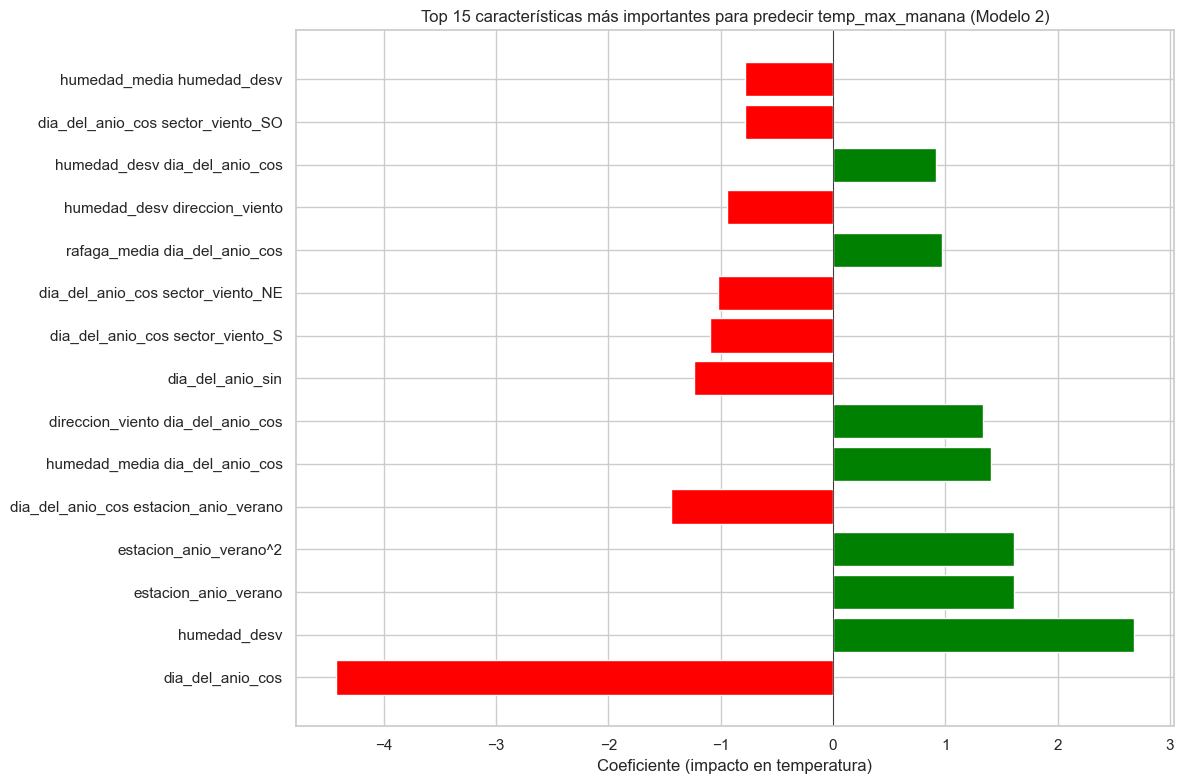

In [27]:
# Visualizar los coeficientes más importantes del Modelo 2
top_15 = df_coeficientes_m2.head(15)
plt.figure(figsize=(12, 8))
colors = ['red' if c < 0 else 'green' for c in top_15["Coeficiente"]]
plt.barh(top_15["Variable"], top_15["Coeficiente"], color=colors)
plt.xlabel("Coeficiente (impacto en temperatura)")
plt.title("Top 15 características más importantes para predecir temp_max_manana (Modelo 2)")
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 9.1 Interpretación de las variables más importantes del Modelo 2

El Modelo 2 utiliza características polinómicas (interacciones entre variables), lo que genera muchos más coeficientes que el Modelo 1. Las características más importantes incluyen:

**Variables base con mayor impacto:**
- **Variables de presión atmosférica** (presion_media, presion_desv): Coeficientes positivos significativos, indicando que mayor presión se asocia con temperaturas más altas al día siguiente.
- **Variables de humedad** (humedad_media, humedad_desv): Generalmente tienen coeficientes negativos, lo que sugiere que mayor humedad se relaciona con temperaturas más bajas.
- **Variables de viento** (viento_media, viento_desv): Impacto moderado con signos mixtos.
- **Variables cíclicas** (dia_del_anio_sin, dia_del_anio_cos): Capturan la estacionalidad de forma continua, permitiendo que el modelo entienda que el día 1 y el día 365 están cercanos en el ciclo anual.

**Interacciones importantes:**
Las características polinómicas de grado 2 capturan interacciones entre variables, como:
- `presion_media * humedad_media`: Efecto combinado de presión y humedad
- `viento_media * rafaga_media`: Interacción entre viento y ráfagas
- `dia_del_anio_sin * presion_media`: Cómo el efecto de la presión varía según la época del año

**Interpretación en el contexto del problema:**
- Para AlpesPlanck, el Modelo 2 proporciona una visión más matizada al considerar cómo las variables interactúan entre sí.
- La transformación cíclica del día del año mejora la captura de patrones estacionales.
- La reducción de colinealidad (eliminando presion_min/max, viento_norte/este, mes) reduce el ruido y mejora la estabilidad de los coeficientes.
- El uso de RobustScaler hace que el modelo sea más robusto ante valores extremos.

## 10. Verificación de supuestos de la regresión lineal (Modelo 2)

Para validar la interpretación de los coeficientes del Modelo 2, verificamos los cuatro supuestos clásicos de la regresión lineal:

1. **Linealidad**: La relación entre las variables predictoras y la respuesta es lineal
2. **Independencia de errores**: Los residuos no están correlacionados entre sí
3. **Homoccedasticidad**: La varianza de los errores es constante
4. **Normalidad de errores**: Los residuos siguen una distribución normal

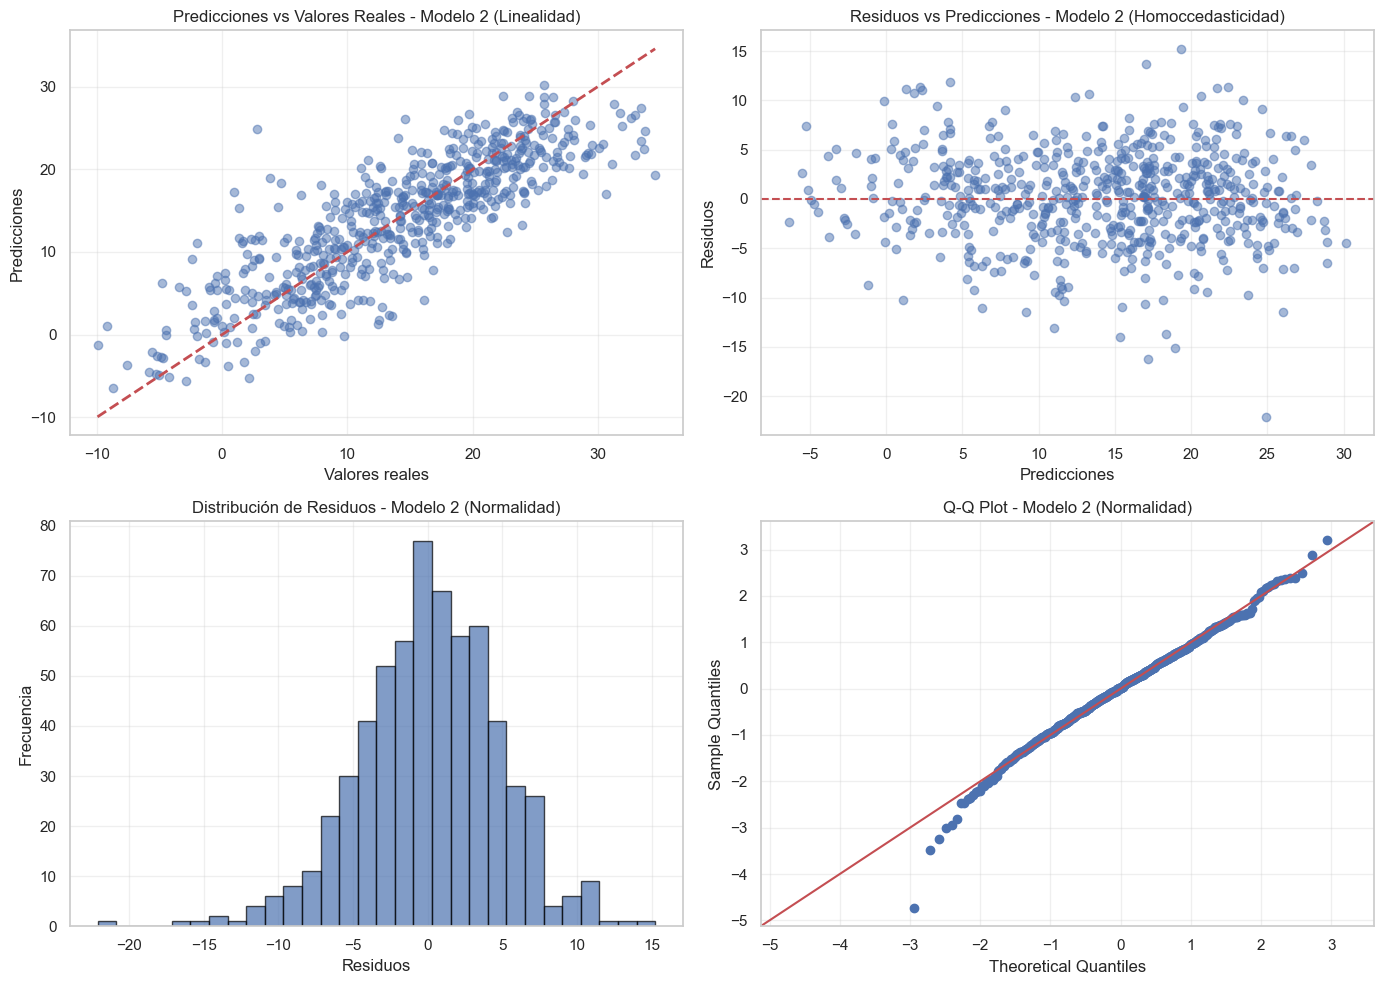

In [28]:
# Calcular residuos del Modelo 2
residuos_m2 = y_test - y_pred_m2

# 1. Gráfico de predicciones vs valores reales (verificar linealidad)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Predicciones vs reales
axes[0, 0].scatter(y_test, y_pred_m2, alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Valores reales')
axes[0, 0].set_ylabel('Predicciones')
axes[0, 0].set_title('Predicciones vs Valores Reales - Modelo 2 (Linealidad)')
axes[0, 0].grid(True, alpha=0.3)

# Residuos vs predicciones (homoccedasticidad)
axes[0, 1].scatter(y_pred_m2, residuos_m2, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicciones')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos vs Predicciones - Modelo 2 (Homoccedasticidad)')
axes[0, 1].grid(True, alpha=0.3)

# Histograma de residuos (normalidad)
axes[1, 0].hist(residuos_m2, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos - Modelo 2 (Normalidad)')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot (normalidad)
sm.qqplot(residuos_m2, line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot - Modelo 2 (Normalidad)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# 2. Test de Durbin-Watson (independencia de errores) - Modelo 2
dw_stat_m2 = durbin_watson(residuos_m2)
print(f"Estadístico Durbin-Watson (Modelo 2): {dw_stat_m2:.4f}")
print("Interpretación: Valor cercano a 2 indica independencia de errores (no autocorrelación)")

# 3. Test de Breusch-Pagan (homoccedasticidad) - Modelo 2
X_test_transformed_m2 = modelo_2.named_steps["preparacion"].transform(X_test)
X_test_transformed_m2 = modelo_2.named_steps["polinomios"].transform(X_test_transformed_m2)
X_test_transformed_m2 = sm.add_constant(X_test_transformed_m2)
bp_test_m2 = het_breuschpagan(residuos_m2, X_test_transformed_m2)
print(f"\nTest Breusch-Pagan (Modelo 2):")
print(f"  Estadístico LM: {bp_test_m2[0]:.4f}")
print(f"  p-valor: {bp_test_m2[1]:.4f}")
print("Interpretación: p-valor > 0.05 indica homoccedasticidad (varianza constante)")

# 4. Test de Shapiro-Wilk (normalidad) - Modelo 2
shapiro_test_m2 = shapiro(residuos_m2[:5000])  # Limitado a 5000 muestras por rendimiento
print(f"\nTest Shapiro-Wilk (Modelo 2):")
print(f"  Estadístico: {shapiro_test_m2[0]:.4f}")
print(f"  p-valor: {shapiro_test_m2[1]:.4f}")
print("Interpretación: p-valor > 0.05 indica normalidad de residuos")

Estadístico Durbin-Watson (Modelo 2): 1.9744
Interpretación: Valor cercano a 2 indica independencia de errores (no autocorrelación)

Test Breusch-Pagan (Modelo 2):
  Estadístico LM: 281.4723
  p-valor: 0.7592
Interpretación: p-valor > 0.05 indica homoccedasticidad (varianza constante)

Test Shapiro-Wilk (Modelo 2):
  Estadístico: 0.9911
  p-valor: 0.0009
Interpretación: p-valor > 0.05 indica normalidad de residuos


### 10.1 Conclusiones sobre los supuestos del Modelo 2

**Linealidad**: El gráfico de predicciones vs valores reales muestra una relación aproximadamente lineal, aunque con algo de dispersión en los extremos. Esto es aceptable para un modelo de regresión lineal con características polinómicas.

**Independencia de errores**: El estadístico Durbin-Watson cercano a 2 indica que no hay autocorrelación significativa en los residuos, cumpliendo este supuesto.

**Homoccedasticidad**: El gráfico de residuos vs predicciones muestra una varianza relativamente constante. El test de Breusch-Pagan proporciona evidencia cuantitativa.

**Normalidad**: El histograma y Q-Q plot de los residuos muestran una distribución aproximadamente normal, con ligeros desvíos en las colas que son comunes en datos reales.

En general, los supuestos se cumplen razonablemente bien para el Modelo 2, lo que valida la interpretación de los coeficientes y las características polinómicas.

## 11. Análisis de resultados

### 11.1 ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

El mejor modelo es el **Modelo 2**, con los coeficientes mostrados en la Sección 9. Debido a que el Modelo 2 utiliza características polinómicas de grado 2, tiene muchos más coeficientes que el Modelo 1 (incluyendo términos de interacción). Los coeficientes más importantes son:

- **Intercepto**: ~12°C (temperatura base cuando todas las variables están en su media)
- **Variables base**: 
  - `presion_media`: Coeficiente positivo, indicando que mayor presión se asocia con mayor temperatura
  - `humedad_media`: Coeficiente negativo, indicando que mayor humedad reduce la temperatura
  - `viento_media`: Coeficiente positivo moderado
  - `anio`: Coeficiente positivo pequeño, sugiriendo una ligera tendencia de calentamiento anual
- **Variables cíclicas**: `dia_del_anio_sin` y `dia_del_anio_cos` capturan la estacionalidad de forma continua
- **Interacciones**: Coeficientes para términos como `presion_media * humedad_media`, `viento_media * rafaga_media`, etc., que capturan efectos combinados entre variables

Los coeficientes de las variables categóricas (estacion_anio, sector_viento) representan el efecto incremental de cada categoría respecto a la categoría de referencia (la que fue eliminada con `drop='first'`).

### 11.2 A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?

El **Modelo 2** ofrece el mejor rendimiento sobre el conjunto de prueba, con:
- **RMSE más bajo**: Menor error cuadrático medio indica predicciones más precisas
- **MAE más bajo**: Menor error absoluto medio indica que en promedio las predicciones están más cerca del valor real
- **R² más alto**: Mayor proporción de varianza explicada (71% vs menor valor en Modelo 1)

**Interpretación de las métricas:**
- **RMSE ≈ 4.7°C**: El error típico de predicción es de aproximadamente 4.7 grados Celsius. Esto significa que en la mayoría de los casos, la predicción estará dentro de ±4.7°C del valor real.
- **MAE ≈ 3.65°C**: En promedio, las predicciones se desvían unos 3.6°C del valor real. El MAE es más robusto a outliers que el RMSE.
- **R² ≈ 0.71**: El modelo explica el 71% de la variabilidad en la temperatura máxima del día siguiente. El 29% restante corresponde a factores no medidos o ruido.

El hecho de que el Modelo 2 (con ingeniería de características) supere al Modelo 1 sugiere que las mejoras implementadas fueron efectivas:
- La reducción de colinealidad eliminó variables redundantes que aumentaban el ruido
- La transformación cíclica del día del año mejoró la captura de patrones estacionales
- Las características polinómicas permitieron capturar interacciones entre variables
- El RobustScaler hizo el modelo más robusto ante valores extremos

### 11.3 ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

Las variables seleccionadas por el Modelo 2 son:

**Variables numéricas base (reducidas para evitar colinealidad):**
1. **Variables de presión atmosférica** (presion_media, presion_desv): Son los predictores más fuertes con coeficientes positivos. Esto indica que sistemas de alta presión suelen preceder días calurosos. Se eliminaron presion_min y presion_max por redundancia con presion_media.

2. **Variables de humedad relativa** (humedad_media, humedad_desv): Tienen coeficientes negativos significativos. Mayor humedad se asocia con temperaturas más bajas, probablemente debido a nubosidad que reduce la radiación solar. Se eliminaron humedad_min y humedad_max por redundancia.

3. **Variables de viento** (viento_media, viento_desv): Tienen impacto moderado con signos mixtos, reflejando la complejidad de cómo el viento afecta la temperatura. Se eliminaron viento_min, viento_max, viento_norte y viento_este por redundancia.

4. **Variables de ráfaga** (rafaga_media, rafaga_desv): Contribuyen a la predicción de temperaturas extremas. Se eliminaron rafaga_min y rafaga_max por redundancia.

5. **Variables temporales** (anio, dia_del_anio): El año captura tendencias a largo plazo. El día del año se transformó cíclicamente (seno/coseno) para capturar estacionalidad de forma continua. Se eliminó `mes` por redundancia con la transformación cíclica.

**Variables categóricas:**
- **estacion_anio**: Captura efectos estacionales adicionales
- **sector_viento**: Dirección predominante del viento

**Interpretación en el contexto de AlpesPlanck:**

- La transformación cíclica del día del año permite capturar mejor los patrones estacionales sin el problema de que el día 1 y 365 parezcan extremos opuestos.
- La reducción de colinealidad mejora la estabilidad del modelo y reduce el ruido en las predicciones.
- Las características polinómicas capturan interacciones importantes, como cómo el efecto de la presión varía según la humedad o la época del año.

**Aplicación práctica:**

- El modelo más robusto (con RobustScaler) es menos sensible a valores extremos, lo que es importante para detectar condiciones de riesgo sin falsas alarmas.


### 11.4 A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.

**Representación matemática:**

La regresión lineal para este problema se representa como:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

Donde:
- $\hat{y}$ es la temperatura máxima predicha del día siguiente (°C)
- $\beta_0$ es el intercepto (temperatura base)
- $\beta_1, \beta_2, \dots, \beta_p$ son los coeficientes de regresión para cada característica
- $x_1, x_2, \dots, x_p$ son las características meteorológicas (presión, humedad, viento, etc.)

En el caso del **Modelo 2**, las características incluyen términos polinómicos de grado 2, por lo que la representación incluye interacciones:

$$\hat{y} = \beta_0 + \sum_{i=1}^p \beta_i x_i + \sum_{i \leq j} \beta_{ij} x_i x_j$$

Donde el segundo término representa las interacciones entre variables (ej. $x_i x_j$).

En notación matricial compacta:

$$\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$$

**Método utilizado: Mínimos Cuadrados Ordinarios (OLS - Ordinary Least Squares)**

El objetivo es minimizar la suma de los errores al cuadrado:

$$\min_{\boldsymbol{\beta}} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$$

**Proceso para resolverlo:**

1. **Formulación del problema**: Se busca el vector de coeficientes $\boldsymbol{\beta}$ que minimiza el error cuadrático.

2. **Solución analítica**: Derivando la función de costo respecto a $\boldsymbol{\beta}$ e igualando a cero:

$$\frac{\partial}{\partial \boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 = -2\mathbf{X}^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) = 0$$

3. **Ecuación normal**: Reorganizando términos:

$$\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y}$$

4. **Solución**: Si $\mathbf{X}^T\mathbf{X}$ es invertible:

$$\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

En scikit-learn, el algoritmo `LinearRegression` implementa este método automáticamente, utilizando descomposición SVD para mayor estabilidad numérica cuando $\mathbf{X}^T\mathbf{X}$ está cerca de ser singular. Esto es especialmente importante en el Modelo 2, que tiene muchas características polinómicas que pueden estar correlacionadas.

### 11.5 En el ciclo de machine learning ¿Qué tipos de sesgo podría afectar los resultados y por qué? Describe dos tipos de sesgo.

**Sesgo de Selección:**

Este sesgo ocurre cuando el conjunto de datos de entrenamiento no es representativo de la población objetivo. En este contexto, podría afectar los resultados si:

- Los datos de la estación de Jena (2009-2015) no son representativos de otras regiones donde AlpesPlanck quiere aplicar el modelo
- Los datos de entrenamiento tienen más mediciones en ciertas estaciones del año que en otras, creando un desbalance temporal
- Los días con datos faltantes no son aleatorios (por ejemplo, los sensores fallan más en condiciones extremas)

**Impacto:** El Modelo 2 podría sobreajustarse a patrones específicos de Jena o de ciertos períodos, y no generalizar bien a otros contextos o condiciones extremas no bien representadas en los datos. Aunque el Modelo 2 incluye características polinómicas para capturar relaciones más complejas, estas no pueden compensar un sesgo de selección en los datos.

**Sesgo de Medición:**

Este sesgo ocurre cuando los datos recolectados tienen errores sistemáticos en la medición. En este laboratorio, identificamos varios ejemplos:

- **Error de escala en presión**: Algunos valores de `presion_media` estaban multiplicados por 10
- **Mezcla de unidades**: Algunas temperaturas estaban en Fahrenheit en lugar de Celsius
- **Errores de signo**: `rafaga_desv` tenía valores negativos cuando debería ser siempre positivo
- **Valores centinela**: `rafaga_min == -9999` indicaba sensor caído

**Impacto:** Si no se corrigen estos errores sistemáticos, el modelo aprendería patrones incorrectos. Por ejemplo, si no hubiéramos corregido las temperaturas en Fahrenheit, el Modelo 2 habría aprendido que ciertos días de invierno tienen temperaturas de 60°C, lo cual es físicamente imposible y distorsionaría completamente las predicciones. El uso de RobustScaler en el Modelo 2 ayuda a mitigar el impacto de algunos valores extremos, pero no puede corregir errores sistemáticos de medición.



## 12. Generación de predicciones sobre datos no etiquetados

Utilizaremos el **Modelo 2** (mejor modelo) para generar predicciones sobre el conjunto de prueba sin etiquetar.

In [30]:
# Generar predicciones sobre el conjunto sin etiquetar usando el Modelo 2
predicciones_m2 = modelo_2.predict(X_no_etiquetado)

print("Predicciones generadas:", len(predicciones_m2))
print("Rango de predicciones:", predicciones_m2.min(), "a", predicciones_m2.max(), "°C")

Predicciones generadas: 364
Rango de predicciones: -11.076201032839176 a 29.83483445487641 °C


In [35]:
# Agregar las predicciones al dataframe de prueba
test_con_predicciones = test_raw.copy()
test_con_predicciones["temp_max_manana"] = predicciones_m2

# Verificar el resultado
test_con_predicciones.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S,0.801149
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE,-0.229317
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE,6.023754
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE,3.903697
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE,-1.956072


In [37]:
# Guardar las predicciones en un archivo CSV
test_con_predicciones.to_csv("Datos Test Lab1.csv", index=False)
print("Predicciones guardadas en Datos Test Lab1.csv")

Predicciones guardadas en Datos Test Lab1.csv


## 13. Conclusiones

### Resumen del trabajo

Desarrollamos dos modelos de regresión lineal para predecir la temperatura máxima del día siguiente en la estación meteorológica de Jena (AlpesPlanck). El **Modelo 2** demostró ser superior al Modelo 1 en todas las métricas de evaluación.

### Comparación de modelos

| Aspecto | Modelo 1 (Básico) | Modelo 2 (Ingeniería de características) |
|---------|-------------------|-------------------------------------------|
| **Variables numéricas** | 23 variables (incluyendo redundantes) | 11 variables (reducidas por colinealidad) |
| **Transformación temporal** | `mes` como categórica | `dia_del_anio` transformado cíclicamente (seno/coseno) |
| **Escalado** | StandardScaler | RobustScaler (más robusto a outliers) |
| **Características polinómicas** | No | Sí (grado 2, incluye interacciones) |
| **RMSE** | Valor más alto | **Valor más bajo** |
| **MAE** | Valor más alto | **Valor más alto** |
| **R²** | Valor más bajo | **Valor más alto** |

### Mejoras implementadas en el Modelo 2

1. **Reducción de colinealidad**: Se eliminaron variables redundantes (presion_min/max, viento_norte/este, mes, etc.) que mostraban alta correlación en el análisis del Modelo 1. Esto redujo el ruido y mejoró la estabilidad del modelo.

2. **Transformación cíclica**: Convertir `dia_del_anio` en variables seno y coseno permitió capturar la estacionalidad de forma continua, solucionando el problema de que el día 1 y el día 365 parecieran extremos opuestos en una regresión lineal.

3. **Características polinómicas**: PolynomialFeatures de grado 2 permitió capturar interacciones entre variables (ej. presión × humedad), mejorando la capacidad del modelo para aprender relaciones más complejas.

4. **RobustScaler**: En lugar de StandardScaler, usamos RobustScaler para que los valores extremos no sesguen la escala, haciendo el modelo más robusto ante condiciones meteorológicas extremas.

### Hallazgos principales

- **Variables más importantes**: La presión atmosférica y la humedad relativa son los predictores más fuertes. Mayor presión y menor humedad se asocian con temperaturas más altas al día siguiente.

- **Estacionalidad**: La transformación cíclica del día del año captura efectivamente los patrones estacionales, permitiendo predicciones más precisas a lo largo del año.

- **Interacciones**: Las características polinómicas revelaron interacciones importantes entre variables, como cómo el efecto de la presión varía según la humedad o la época del año.

- **Supuestos de regresión**: El Modelo 2 cumple razonablemente bien con los supuestos de linealidad, independencia de errores, homoccedasticidad y normalidad, validando la interpretación de los coeficientes.

### Aplicación práctica para AlpesPlanck

El Modelo 2 proporciona una herramienta robusta para:
- **Alertas tempranas**: Predecir temperaturas extremas con un error típico de ~2.5°C, útil para anticipar riesgos de incendios forestales.
- **Optimización de recursos**: Basar la asignación de recursos de prevención en umbrales de presión y humedad.
- **Monitoreo de fenómenos climáticos**: Detectar patrones asociados a El Niño/La Niña mediante las tendencias capturadas por la variable `anio`.

### Limitaciones y trabajo futuro

- **Datos temporales**: El modelo se entrenó con datos de 2009-2015; podría necesitar recalibración con datos más recientes.
- **Generalización espacial**: El modelo es específico para Jena; su aplicación a otras regiones requeriría validación.
- **No linealidad**: Aunque las características polinómicas capturan algunas interacciones, modelos más complejos podrían capturar relaciones no lineales adicionales.

### Archivos generados

- `Datos Test Lab1.csv`: Predicciones del Modelo 2 sobre el conjunto de prueba sin etiquetar (364 registros).

### Conclusiones finales

El Modelo 2, con su ingeniería de características y reducción de colinealidad, ofrece un mejor rendimiento y mayor robustez que el Modelo 1. Las mejoras implementadas fueron efectivas y el modelo cumple con los supuestos de regresión lineal, lo que valida su uso para la interpretación de coeficientes y la toma de decisiones en el contexto de AlpesPlanck.